In [1]:
CIBUSmod_dir = '..'
output_dir = '../../MFF-scenarios/output'
scn_name = 'MFF'

In [2]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),CIBUSmod_dir))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Create session
session = cm.Session(
    name = scn_name,
    data_path = os.path.join(CIBUSmod_dir,'data'),
    data_path_output = output_dir
)

In [27]:
c_area = session.get_attr('C','area',
                          {'crop':'land_use','region':None,'prod_system':None}, interpolate=True).loc[:,'cropland']

<Axes: xlabel='year', ylabel='kg/ha'>

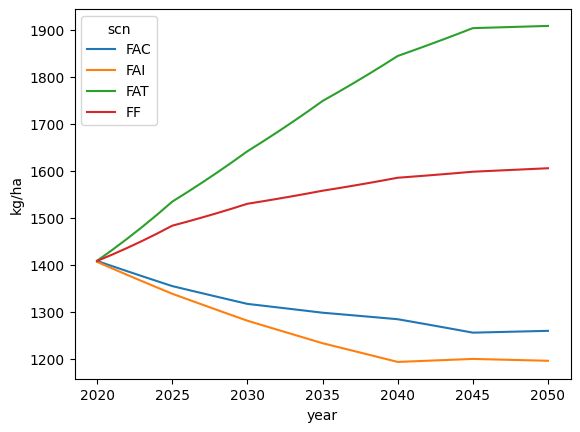

In [32]:
d = session.get_attr('C','fertiliser.crop_residues_C',
                 {'crop':'land_use','region':None,'prod_system':None,'residue':None}, interpolate=True).loc[:,'cropland']
d.sum(axis=1).div(c_area.sum(axis=1)).unstack('scn').plot(ylabel='kg/ha')

<Axes: xlabel='year', ylabel='kg/ha'>

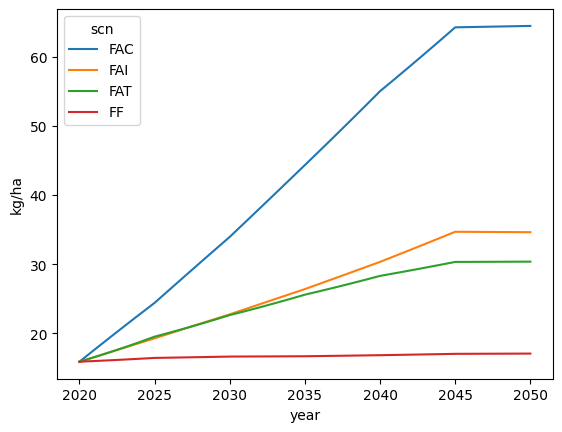

In [33]:
d = session.get_attr('C','fertiliser.cover_crop_residues_C',
                 {'crop':'land_use','region':None,'prod_system':None,'residue':None}, interpolate=True).loc[:,'cropland']
d.sum(axis=1).div(c_area.sum(axis=1)).unstack('scn').plot(ylabel='kg/ha')

<Axes: xlabel='year', ylabel='kg/ha'>

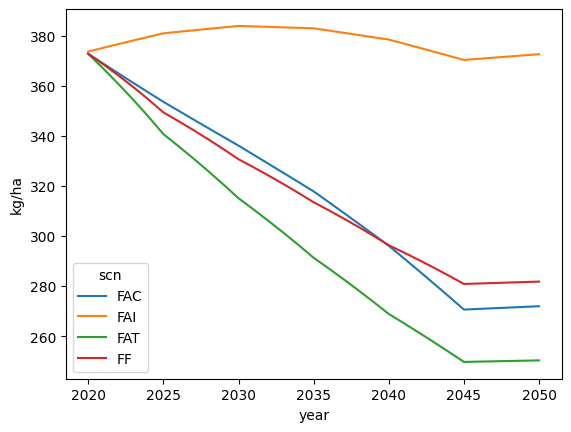

In [34]:
d = session.get_attr('C','fertiliser.manure_C',
                 {'crop':'land_use','region':None,'prod_system':None}, interpolate=True).loc[:,'cropland']
d.sum(axis=1).div(c_area.sum(axis=1)).unstack('scn').plot(ylabel='kg/ha')

<Axes: xlabel='year', ylabel='kg/ha'>

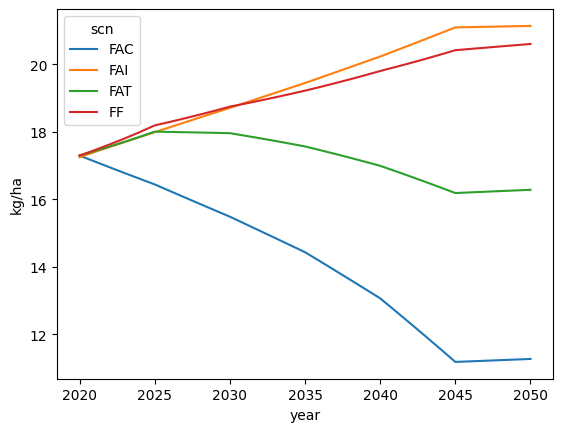

In [35]:
d = session.get_attr('C','fertiliser.organic_C',
                 {'crop':'land_use','region':None,'prod_system':None}, interpolate=True).loc[:,'cropland']
d.sum(axis=1).div(c_area.sum(axis=1)).unstack('scn').plot(ylabel='kg/ha')

<Axes: xlabel='crop', ylabel='kg/ha'>

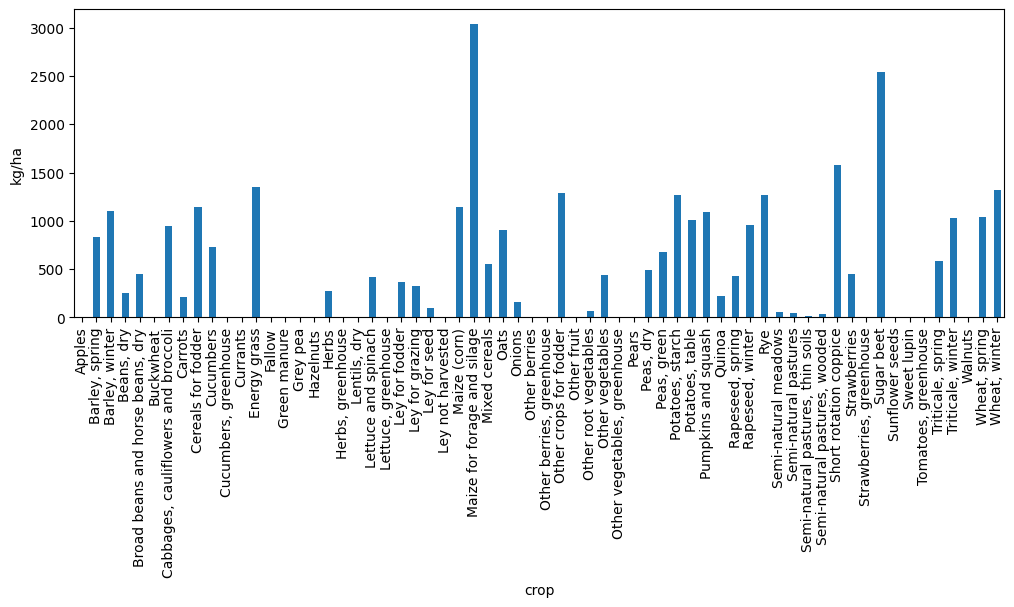

In [47]:
# Check crop residue C per crop
(session.get_attr('C','fertiliser.crop_residues_C',['residue','crop']).loc[:,'below ground'] / session.get_attr('C','area',['crop'])).loc[('FAI','2020')].plot.bar(figsize=(12,4),ylabel='kg/ha')